# Denoising Diffusion Models (DDPM & DDIM) 


In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

FOLDERNAME = 'training_zen/phase2/assignment2_2'
assert FOLDERNAME is not None, "[!] Enter the foldername."

import sys
sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

%cd /content/drive/My\ Drive/$FOLDERNAME

Mounted at /content/drive
/content/drive/My Drive/training_zen/phase2/assignment2_2


In [2]:
print(FOLDERNAME)

training_zen/phase2/assignment2_2


## Datasets download

In [ ]:
# # Move to dataset directory and run the downloader bash script
# %cd dataset
# !bash get_dataset.sh
# # Return back to the project root directory
# %cd ..

In [3]:
!pip install -q --upgrade-strategy only-if-needed -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 26.6 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 9.1 MB/s eta 0:00:00


In [6]:
!pip install IPython==8.18.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 808.2/808.2 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 103.2 MB/s eta 0:00:0000:01
  Attempting uninstall: IPython
    Found existing installation: ipython 7.34.0
    Uninstalling ipython-7.34.0:
      Successfully uninstalled ipython-7.34.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipython==7.34.0, but you have ipython 8.18.1 which is incompatible.


In [7]:
%load_ext autoreload
%autoreload 2


## Tests

In [8]:
!python -m unittest discover -s test -p "test_*.py"


=== RUNNING CELEBA DDPM DATASET FALLBACK TEST ===
Successfully loaded 8 CelebA images using FlatImageDataset fallback.
CelebA Mock Train split size: 4
CelebA Mock Val split size: 2
CelebA Mock Test split size: 2
Batch shape: torch.Size([2, 3, 32, 32])
Batch value range: [-0.765, 0.773]
Logging 2 sample images:
  - Item 1: Shape=torch.Size([3, 32, 32]), Mean=-0.1190, Std=0.6513
  - Item 2: Shape=torch.Size([3, 32, 32]), Mean=-0.1216, Std=0.3012
.
=== RUNNING MNIST DDPM DATASET TEST ===
100% 9.91M/9.91M [00:00<00:00, 20.5MB/s]
100% 28.9k/28.9k [00:00<00:00, 487kB/s]
100% 1.65M/1.65M [00:00<00:00, 4.66MB/s]
100% 4.54k/4.54k [00:00<00:00, 14.7MB/s]
MNIST Train split size: 54000
MNIST Val split size: 6000
MNIST Test split size: 10000
Batch shape: torch.Size([4, 1, 32, 32])
Batch value range: [-1.000, 0.992]
Logging 3 sample images:
  - Item 1: Shape=torch.Size([1, 32, 32]), Mean=-0.7240, Std=0.5995
  - Item 2: Shape=torch.Size([1, 32, 32]), Mean=-0.7374, Std=0.5839
  - Item 3: Shape=torch.

In [9]:

import wandb
wandb.login()

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: tam-vd230064 (tam-vd230064-hanoi-university-of-science-and-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## Train DDPM

In [10]:
# loaded from config.yaml
!python main.py --config config.yaml

======= DDPM Training Config Override =======
batch_size: 128
data_dir: ./data
dataset: mnist
diffusion:
  beta_end: 0.02
  beta_start: 0.0001
  num_timesteps: 1000
  schedule_name: linear
image_size: 32
model:
  hidden_dims:
  - 64
  - 128
  - 256
  - 256
  in_channels: 1
  time_emb_dim: 256
num_workers: 2
training:
  checkpoint_dir: ./checkpoints
  device: cuda
  epochs: 50
  fid_interval: 10
  learning_rate: 0.0002
  num_fid_samples: 200
  sample_interval: 5
  wandb_project: DDPM-Training
  weight_decay: 0.0
val_split_ratio: 0.1

Using device: cuda
Initializing Weights & Biases (wandb) run...
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: tam-vd230064 (tam-vd230064-hanoi-university-of-science-and-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: Tracking run with wandb version 0.27.0
wandb: Run data is 

## Infer

- Generate random samples using the saved model checkpoint. 

- Use **DDPM** sampler (1000 steps)  **DDIM** sampler (50 steps).

In [11]:
#DDPM sampling (1000 steps)
!python infer/samplers.py --checkpoint checkpoints/best_checkpoint.pth --sampler ddpm --num_samples 16 --output_dir colab_results

#DDIM sampling (50 steps)
!python infer/samplers.py --checkpoint checkpoints/best_checkpoint.pth --sampler ddim --ddim_steps 50 --num_samples 16 --output_dir colab_results

Using device for inference: cuda
Pre-trained model loaded successfully.
Sampling 16 images using DDPM (stochastic 1000 steps)...
Successfully saved generation grid to: colab_results/generated_ddpm_s16.png
Using device for inference: cuda
Pre-trained model loaded successfully.
Sampling 16 images using DDIM (deterministic 50 steps)...
Successfully saved generation grid to: colab_results/generated_ddim_s16.png


## Visualize Generated Samples

=== DDIM Generated Samples (50 steps) ===


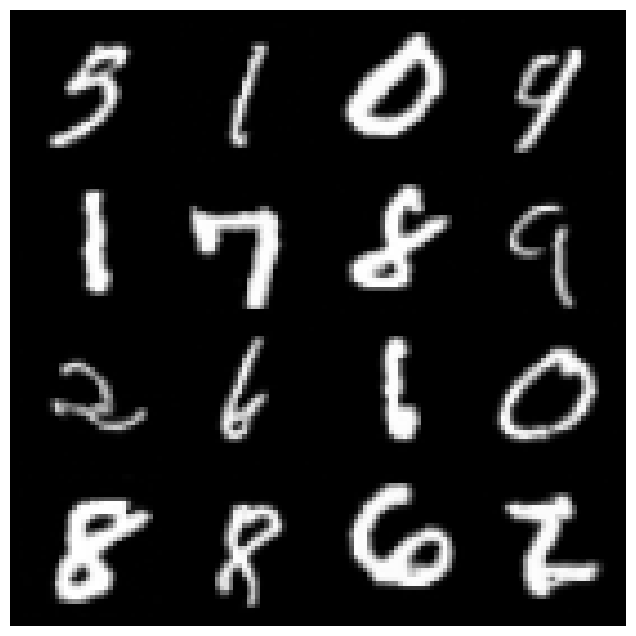

=== DDPM Generated Samples (1000 steps) ===


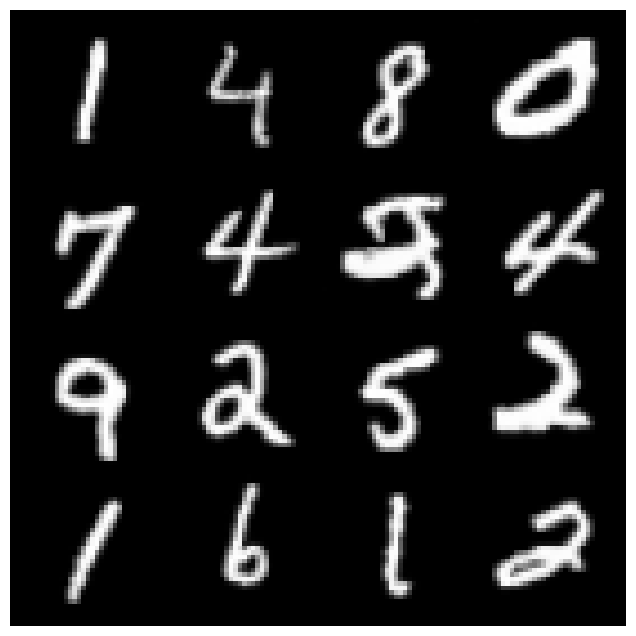

In [12]:
import os
import matplotlib.pyplot as plt
from PIL import Image

ddim_grid = 'colab_results/generated_ddim_s16.png'
ddpm_grid = 'colab_results/generated_ddpm_s16.png'

# Show DDIM Grid
if os.path.exists(ddim_grid):
    print("=== DDIM Generated Samples (50 steps) ===")
    plt.figure(figsize=(8, 8))
    plt.imshow(Image.open(ddim_grid))
    plt.axis('off')
    plt.show()
else:
    print("[!] DDIM sample grid not found. Run inference first!")

# Show DDPM Grid
if os.path.exists(ddpm_grid):
    print("=== DDPM Generated Samples (1000 steps) ===")
    plt.figure(figsize=(8, 8))
    plt.imshow(Image.open(ddpm_grid))
    plt.axis('off')
    plt.show()
else:
    print("[!] DDPM sample grid not found. Run inference first!")